In [71]:
# Importing required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().round()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,4.0,121.0,69.0,21.0,80.0,32.0,0.0,33.0,0.0
std,3.0,32.0,19.0,16.0,115.0,8.0,0.0,12.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.0,0.0,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.0,32.0,0.0,29.0,0.0
75%,6.0,140.0,80.0,32.0,127.0,37.0,1.0,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.0,2.0,81.0,1.0


In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin',
       'bmi', 'diabetespedigreefunction', 'age', 'outcome'],
      dtype='str')

In [6]:
df.isnull().sum()

pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64

In [7]:
df.describe().round()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,4.0,121.0,69.0,21.0,80.0,32.0,0.0,33.0,0.0
std,3.0,32.0,19.0,16.0,115.0,8.0,0.0,12.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.0,0.0,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.0,32.0,0.0,29.0,0.0
75%,6.0,140.0,80.0,32.0,127.0,37.0,1.0,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.0,2.0,81.0,1.0


In [8]:
df.outcome.value_counts()

outcome
0    500
1    268
Name: count, dtype: int64

In [9]:
cols = ['glucose','bloodpressure', 'skinthickness', 'insulin', 'bmi']
df[cols] = df[cols].replace(0, np.nan)

In [10]:
df.isnull().sum()

pregnancies                   0
glucose                       5
bloodpressure                35
skinthickness               227
insulin                     374
bmi                          11
diabetespedigreefunction      0
age                           0
outcome                       0
dtype: int64

In [11]:
cols = ['glucose','bloodpressure', 'skinthickness', 'insulin', 'bmi']
for col in cols:
    df[col]=df[col].replace(np.nan, df[col].median())

outcome
0    500
1    268
Name: count, dtype: int64


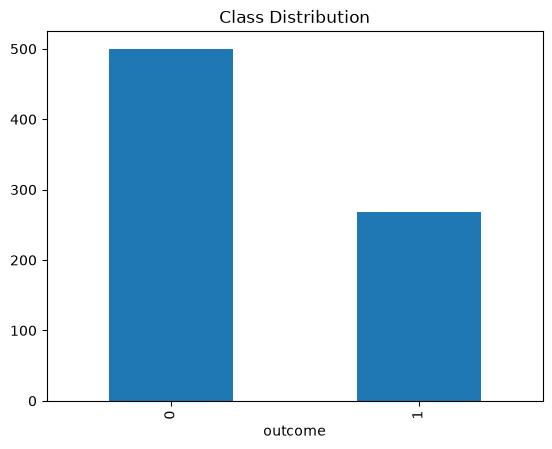

In [12]:
print(df.outcome.value_counts())
df.outcome.value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report


In [14]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=7)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=7)

In [15]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [16]:
df_train.outcome.value_counts()

outcome
0    308
1    152
Name: count, dtype: int64

In [17]:
max = df_train[df_train.outcome==0]
min = df_train[df_train.outcome==1]
upsample = resample(min, replace=True, n_samples=308, random_state=7)
df_train = pd.concat([upsample, max])

In [18]:
df_train.outcome.value_counts()

outcome
1    308
0    308
Name: count, dtype: int64

In [19]:
y_train = df_train.outcome
y_val = df_val.outcome
y_test = df_test.outcome

In [20]:
del df_train['outcome']
del df_val['outcome']
del df_test['outcome']

In [21]:
len(df_train), len(df_test), len(df_val)

(616, 154, 154)

In [22]:
X_train = df_train
X_val = df_val
X_test = df_test


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

In [24]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
y_pred = dt.predict_proba(X_val)[:, 1]
y_pred

array([1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0.,
       0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0.,
       1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1.,
       1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1.,
       0.])

In [26]:
roc_auc_score(y_val, y_pred)

0.6796610169491525

In [27]:
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print(f"{d} -> {auc}")

1 -> 0.5902765388046387
2 -> 0.7028545941123997
3 -> 0.7482604817127564
4 -> 0.7709188224799286
5 -> 0.7731489741302409
6 -> 0.7555753791257807
10 -> 0.6735057983942908
15 -> 0.6926851025869759
20 -> 0.7156110615521856
None -> 0.6776092774308653


In [28]:
samples = [1, 5, 10, 15, 20, 30, 40, 45, 50, 60, 80, 100, 200]
for s in samples:
    dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=s)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print(f"{s} -> {auc}")


1 -> 0.7760035682426406
5 -> 0.7439785905441569
10 -> 0.7305084745762712
15 -> 0.715700267618198
20 -> 0.7353256021409456
30 -> 0.7438001784121321
40 -> 0.7449598572702943
45 -> 0.7338983050847457
50 -> 0.7371097234611954
60 -> 0.727564674397859
80 -> 0.7322033898305085
100 -> 0.7336306868867083
200 -> 0.6551293487957182


In [29]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [30]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7656556645851919

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [32]:
rf = RandomForestClassifier(random_state=7)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
roc_auc_score(y_val, y_pred)

0.7007136485280998

In [33]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7689562890276539

In [34]:
scores = []
for n in range(10, 301, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=7)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [35]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

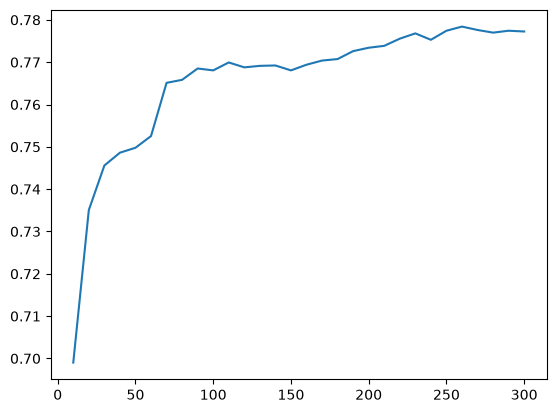

In [36]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [37]:
scores = []
for n in [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, None]:
    rf = RandomForestClassifier(n_estimators=260, max_depth=n, random_state=7)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

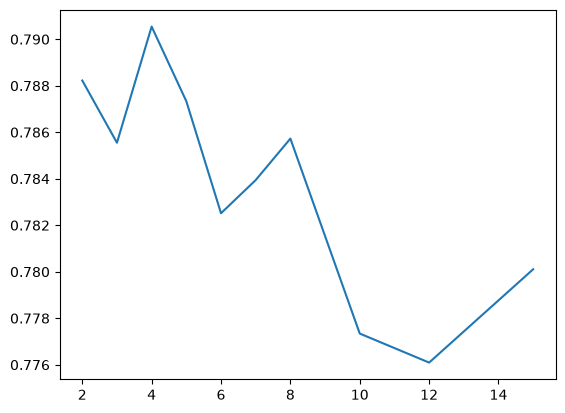

In [38]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'auc'])
plt.plot(df_scores.max_depth, df_scores.auc)

In [39]:
scores = []
for n in [1, 2, 3, 4, 5, 10, 15, 20]:
    rf = RandomForestClassifier(n_estimators=260, max_depth=4, min_samples_leaf=n, random_state=7)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

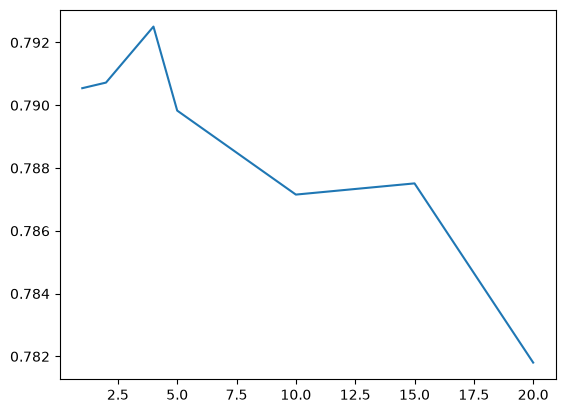

In [40]:
df_scores = pd.DataFrame(scores, columns=['min_samples_leaf', 'auc'])
plt.plot(df_scores.min_samples_leaf, df_scores.auc)

In [41]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7700267618198038

In [42]:
rf = RandomForestClassifier(n_estimators=260, random_state=7)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7784121320249777

In [43]:
rf = RandomForestClassifier(n_estimators=260, max_depth=4, random_state=7)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7905441570026762

In [44]:
rf = RandomForestClassifier(n_estimators=260, max_depth=4, min_samples_leaf=4, random_state=7)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7925066904549509

In [45]:
from xgboost import XGBClassifier

In [46]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7211418376449599

In [47]:
scores =[]
for n in [5, 10, 50, 100, 150, 200, 250, 300]:
    xgb = XGBClassifier(n_estimators=n, random_state = 7)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict_proba(X_val)[:, 1]
    roc_auc_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


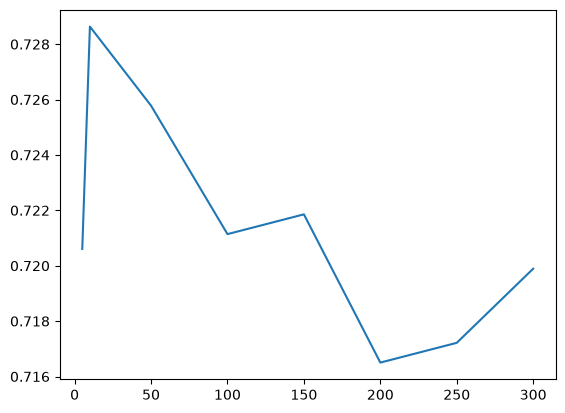

In [48]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
plt.plot(df_scores.n_estimators, df_scores.auc)

In [49]:
scores =[]
for n in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    xgb = XGBClassifier(n_estimators=10, max_depth = n, random_state = 7)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict_proba(X_val)[:, 1]
    roc_auc_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


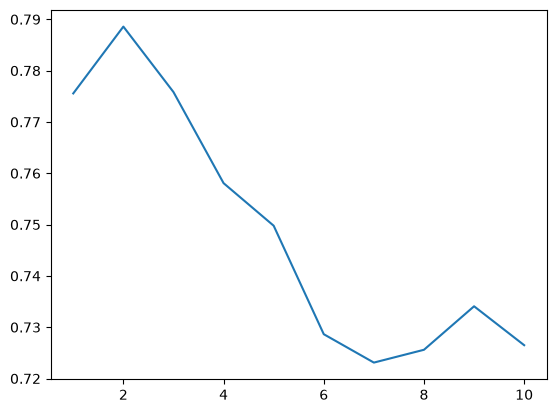

In [50]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'auc'])
plt.plot(df_scores.max_depth, df_scores.auc)

In [51]:
scores =[]
for n in [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.2, 0.3, 0.5, 0.7, 1]:
    xgb = XGBClassifier(n_estimators = 10, max_depth=2, learning_rate=n, random_state = 7)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict_proba(X_val)[:, 1]
    roc_auc_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


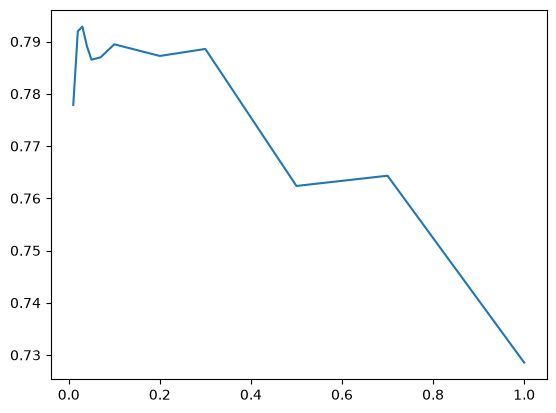

In [52]:
df_scores = pd.DataFrame(scores, columns=['learning_rate', 'auc'])
plt.plot(df_scores.learning_rate, df_scores.auc)

In [53]:
scores =[]
for n in [5, 10, 50, 100, 150, 200, 250, 300]:
    xgb = XGBClassifier(n_estimators = n, max_depth=2, learning_rate=0.03, random_state = 7)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict_proba(X_val)[:, 1]
    roc_auc_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


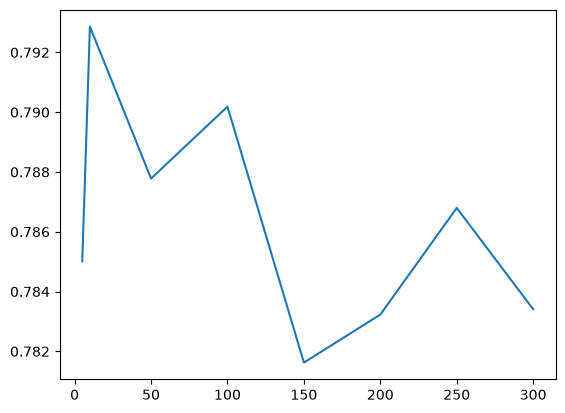

In [54]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
plt.plot(df_scores.n_estimators, df_scores.auc)

In [55]:
scores =[]
for n in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    xgb = XGBClassifier(n_estimators = 10, max_depth=2, learning_rate=0.03, subsample=n, random_state = 7)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict_proba(X_val)[:, 1]
    roc_auc_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


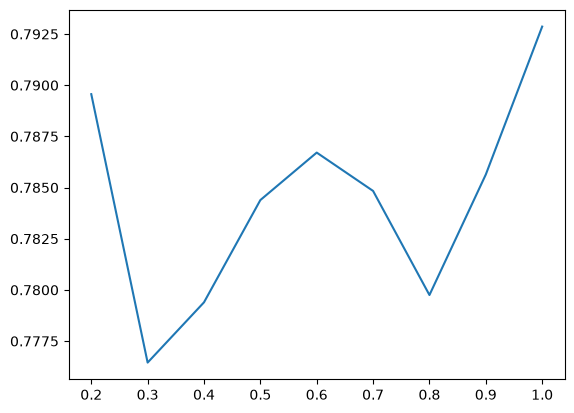

In [56]:
df_scores = pd.DataFrame(scores, columns=['subsamples', 'auc'])
plt.plot(df_scores.subsamples, df_scores.auc)

In [57]:
scores =[]
for n in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    xgb = XGBClassifier(n_estimators = 10, max_depth=2, learning_rate=0.03, subsample=1, colsample_bytree= n, random_state = 7)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict_proba(X_val)[:, 1]
    roc_auc_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


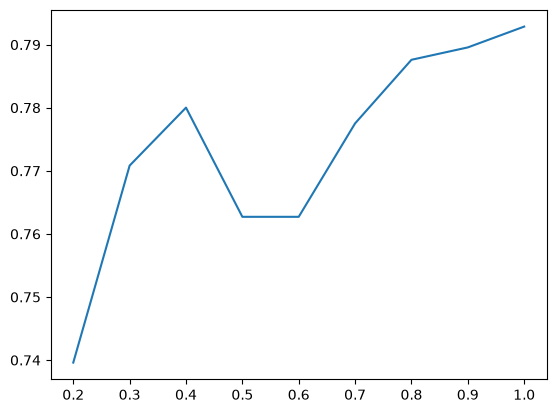

In [58]:
df_scores = pd.DataFrame(scores, columns=['colsample_bytree', 'auc'])
plt.plot(df_scores.colsample_bytree, df_scores.auc)

In [59]:
xgb = XGBClassifier(n_estimators = 10, random_state = 7)
xgb.fit(X_train, y_train)
y_pred = xgb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7286351471900089

In [60]:
xgb = XGBClassifier(n_estimators = 10, max_depth=2, random_state = 7)
xgb.fit(X_train, y_train)
y_pred = xgb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7885816235504015

In [61]:
xgb = XGBClassifier(n_estimators = 10, max_depth=2, learning_rate=0.03, random_state = 7)
xgb.fit(X_train, y_train)
y_pred = xgb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)


0.7928635147190009

In [62]:
xgb = XGBClassifier(n_estimators = 10, max_depth=2, learning_rate=0.03, subsample=1, random_state = 7)
xgb.fit(X_train, y_train)
y_pred = xgb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)


0.7928635147190009

In [70]:
dt_final = DecisionTreeClassifier(max_depth=5, random_state=7)
dt_final.fit(X_train, y_train)
y_dt_pred = dt_final.predict(X_test)
y_dt_prob = dt_final.predict_proba(X_test)[:, 1]

rf_final = RandomForestClassifier(n_estimators=260, max_depth=4, min_samples_leaf=4, random_state=7)
rf_final.fit(X_train, y_train)
y_rf_pred = rf_final.predict(X_test)
y_rf_prob = rf_final.predict_proba(X_test)[:, 1]

xgb_final = XGBClassifier(n_estimators = 10, max_depth=2, learning_rate=0.03, subsample=1, colsample_bytree= 1, random_state = 7)
xgb_final.fit(X_train, y_train)
y_xgb_pred = xgb_final.predict(X_test)
y_xgb_prob = xgb_final.predict_proba(X_test)[:, 1]

print("Decision Tree: ")
print("Accuracy: ", accuracy_score(y_test, y_dt_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_dt_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_dt_pred))
print("classification_report:\n ", classification_report(y_test, y_dt_pred))

print("\nRandom Forest: ")
print("Accuracy: ", accuracy_score(y_test, y_rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_rf_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_rf_pred))
print("classification_report:\n ", classification_report(y_test, y_rf_pred))

print("\nXGBoost: ")
print("Accuracy: ", accuracy_score(y_test, y_xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_xgb_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_xgb_pred))
print("classification_report: \n", classification_report(y_test, y_xgb_pred))

Decision Tree: 
Accuracy:  0.7597402597402597
ROC-AUC: 0.7892023874118286
Confusion Matrix: 
 [[72 25]
 [12 45]]
classification_report:
                precision    recall  f1-score   support

           0       0.86      0.74      0.80        97
           1       0.64      0.79      0.71        57

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.78      0.76      0.76       154


Random Forest: 
Accuracy:  0.7727272727272727
ROC-AUC: 0.841381805028034
Confusion Matrix: 
 [[72 25]
 [10 47]]
classification_report:
                precision    recall  f1-score   support

           0       0.88      0.74      0.80        97
           1       0.65      0.82      0.73        57

    accuracy                           0.77       154
   macro avg       0.77      0.78      0.77       154
weighted avg       0.79      0.77      0.78       154


XGBoost: 
Accuracy:  0.7662337662337663
ROC-AUC: 0.8048471694700668
C